In [1]:
# USE KAIJU/KAIPY KERNEL
import os
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.time import Time #For converting MJD to datetime
plt.style.use('~/plots/paper.mplstyle')
import itertools # For doing 3D loop at least somewhat sensibly
import sympy # For spherical gradients

import kaipy.kaiViz as kv
import kaipy.kaiH5 as kh5
import kaipy.gamera.magsphere as msph
import kaipy.gamera.msphViz as msphViz
import kaipy.remix.remix as remix
import kaipy.kaiTools as ktools
import kaipy.supermage as smage

import ensemble_lib as el
import supermag_api as smapi #Acquired from https://supermag.jhuapl.edu/mag/lib/content/api/supermag-api.py

# Just trying out these colors, they ought to be changed in the future
r = '#BB3E03'
g = '#AE2012'
b = '#005F73'

def find_footpoint(eb_file, step, t, p):
    '''
    Find ionospheric vector footpoints (GAMERA SM X/Y/Z RE) of a given ionospheric SM polar position (requries slice file)
    '''
    conn_pos = np.zeros((eb_file[f'Step#{step}']['xP'].shape[0],eb_file[f'Step#{step}']['xP'].shape[1],2)) # Ionospheric footpoints of each grid cell POLAR
    conn_pos[:, :, 0] = np.rad2deg(np.arctan2(eb_file[f'Step#{step}']['yP'][:,:], eb_file[f'Step#{step}']['xP'][:,:])) # THETA
    conn_pos[(conn_pos[:, :, 0] < 0), 0] += 360 # Make it go from 0 - 360
    conn_pos[:, :, 1] = np.rad2deg(np.arccos(eb_file[f'Step#{step}']['zP'][:,:])) # PHI
    connected_loc = np.unravel_index(np.nanargmin(np.sqrt(np.sum((conn_pos - np.asarray([t, p]))**2, axis = -1))), eb_file[f'Step#{step}']['xP'].shape) # Distance metric (not quite right but euclidean is fine for finding min)
    return (eb_file[f'X'][connected_loc], eb_file[f'Y'][connected_loc]), connected_loc

/glade/work/cobrien/conda-envs/kaiju-3.12/lib/python3.12/site-packages/bezpy/mt/io.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
rundir = "/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high"
runid = "dptd-prime-high"
deltabid = "deltab_lowres"
sliceid = "eb"
step = 589 # Max currents in the GIC prediction for this run
bw_geocoords = [274.6, 48] # Boundary waters station GEO lon/lat in degrees
lon_idx, lat_idx = el.lonlat_tf(bw_geocoords[0], bw_geocoords[1]) # Transform desired geo lon/lat to indices to pull mlon/mlat out of deltab file

db = h5py.File(os.path.join(rundir, f"{runid}.{deltabid}.h5"), "r") # Load the deltab file
eb = h5py.File(os.path.join(rundir, f"{runid}.{sliceid}.h5"), "r") # Load the slice file

gsph = msph.GamsphPipe(rundir, runid, doFast=False)
ion = remix.remix(rundir + f"/{runid}.mix.h5",step-1)
ion.init_vars(hemisphere = 'north')

Initializing Earth magnetosphere
Opening pipe: /glade/derecho/scratch/cobrien/doctor-patient-day-prime-high : dptd-prime-high
/glade/derecho/scratch/cobrien/doctor-patient-day-prime-high/dptd-prime-high.h5 not found, looking for MPI database
	Found 16 = (4,4,1) ranks
Found 1442 timesteps
	Time = [-7200.000000,86400.004344]
	Steps = [0,1441]
Grid size = (96,96,128)
	Cells = 1.179648e+06
Variables (Root/Step) = (8,23)
	Root: ['Bx0', 'BxD', 'By0', 'ByD', 'Bz0', 'BzD', 'dV', 'timeAttributeCache']
	Step: ['Bx', 'By', 'Bz', 'Cs', 'D', 'Jx', 'Jy', 'Jz', 'P', 'Pb', 'SrcDT', 'SrcD_COLD', 'SrcD_RING', 'SrcIONEx', 'SrcIONEy', 'SrcIONEz', 'SrcP_COLD', 'SrcP_RING', 'SrcX1', 'SrcX2', 'Vx', 'Vy', 'Vz']
GameraPipe: b'EARTH'
setting UnitsID
Units Type = EARTH
dptd-prime-high/Grid |●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●| 16/16 [100%] in 0.0s (482.92/s) 
Found MJD data
	Time (Min/Max) = 56367.916667/56369.000000
Found ReMIX data, reading ...
GameraPipe: b'ReMIX'
setting UnitsID
|●●●●●●●●●●●●●●●●●●●●●●●●●●●●●●| 1

In [3]:
bw_smcoords = [db[f'Step#{step}']['smlon'][0, lon_idx, lat_idx], db[f'Step#{step}']['smlat'][0, lon_idx, lat_idx]]
r = 1 # Earth's surface
theta = bw_smcoords[0] # Measured from noon MLT toward +y TODO: Convert from GEO directly
phi = 90 - bw_smcoords[1] # Measured from +z axis, unlike bw_smcoords

loc = np.array([
    r * np.sin(np.deg2rad(phi)) * np.cos(np.deg2rad(theta)),
    r * np.sin(np.deg2rad(phi)) * np.sin(np.deg2rad(theta)),
    r * np.cos(np.deg2rad(phi)),
]) # Location in space of the Boundary Waters station
nhat = np.array([
    r * np.sin(np.deg2rad(90 - phi)) * np.cos(np.deg2rad(theta - 180)),
    r * np.sin(np.deg2rad(90 - phi)) * np.sin(np.deg2rad(theta - 180)),
    r * np.cos(np.deg2rad(90 - phi)),
]) # Northward unit vector

dptd-prime-high/Step#589/Bz    |∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙| 16/16 [100%] in 0.0s (1549.72/s) 
dptd-prime-high/Step#589/Bz    |∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙| 16/16 [100%] in 0.0s (1919.01/s) 


/glade/derecho/scratch/cobrien/tmp/ipykernel_77749/4225384356.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barHall.set_ticklabels(labelsHall)
/glade/derecho/scratch/cobrien/tmp/ipykernel_77749/4225384356.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  barFAC.set_ticklabels(labelsFAC)


dptd-prime-high/Step#589/Jx    |∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙| 16/16 [100%] in 0.0s (1126.44/s) 
dptd-prime-high/Step#589/Jy    |∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙| 16/16 [100%] in 0.0s (976.72/s) 
dptd-prime-high/Step#589/Jz    |∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙∙| 16/16 [100%] in 0.0s (1264.48/s) 


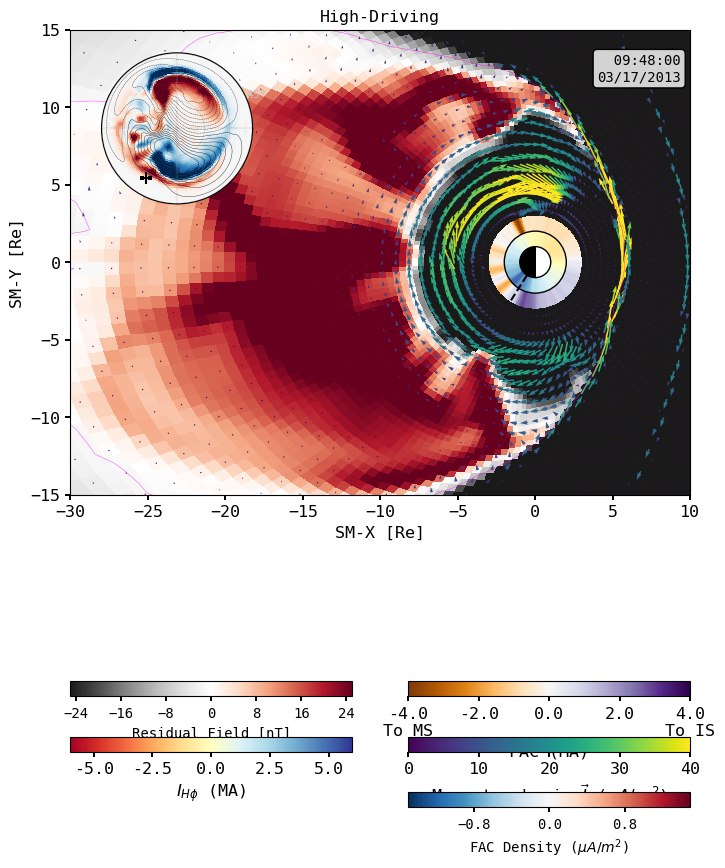

In [4]:
# Plot a snapshot of the magnetosphere at each time for the combined paper figure
step = 589

#Setup figure
figSz = (8, 12)
fig = plt.figure(figsize=figSz)
gs = mpl.gridspec.GridSpec(4,2,height_ratios=[5,0.1,0.1,0.1])
szBd = [-30.0 ,10.0,40.0/15.0]
xTail = szBd[0]
xSun  = szBd[1]
yMax = (xSun-xTail)/szBd[2]
xyBds = [xTail,xSun,-yMax,yMax]

Ax = fig.add_subplot(gs[0, :]) # Run axes

AxC1 = fig.add_subplot(gs[1, 0]) # Residual field colorbar
AxC2 = fig.add_subplot(gs[1, 1]) # FAC colorbar
AxC3 = fig.add_subplot(gs[2, 0]) # JH colorbar
AxC4 = fig.add_subplot(gs[2, 1]) # MS Current vector field colorbar
AxC5 = fig.add_subplot(gs[3, 1]) # Inset FAC colorbar

Bz = msphViz.PlotEqB(gsph,step,xyBds,Ax,AxC1,doBz=False) # Left plot (run 1)
Ax.set_title('High-Driving')

gsph.AddTime(step,Ax,xy=[0.85,0.89]) # Add the time
gsIon = gs[0, :].subgridspec(20, 20) # Below is via msphViz.AddIonBoxes
wXY = 5
dX = 1
dY = 4
AxI = ion.plot('current', gs=gsIon[dY:dY+wXY, dX:dX+wXY], doInset=True)
AxI.scatter(np.deg2rad(theta), np.sin(np.deg2rad(phi)), color = 'k', marker='+', s = 75) # Add boundary waters station to FAC inset
kv.genCB(AxC5, mpl.colors.CenteredNorm(0, 1.5), r'FAC Density ($\mu A / m^2$)', cM = mpl.cm.RdBu_r, Ntk = 4)

#Add Hall Current dial plots
hall_x = np.asarray([1*np.cos(ion.ion['THETA'][0,:]), 2*np.cos(ion.ion['THETA'][0,:])]) # pcolormesh x array
hall_y = np.asarray([1*np.sin(ion.ion['THETA'][0,:]), 2*np.sin(ion.ion['THETA'][0,:])]) # pcolormesh y array
hall_mean = np.asarray([np.sum(-1*ion.hCurrents()[7]*ion.calcFaceAreas(ion.ion['X'], ion.ion['Y'])*6500.e3*6500.e3*24/1.e12, axis = 0)]) # Binned data in pcolormesh shape NOTE: this is -JH_phi
meshHall = Ax.pcolormesh(hall_x, hall_y, hall_mean, norm = mpl.colors.CenteredNorm(0, 6), cmap = mpl.cm.RdYlBu)
barHall = plt.colorbar(meshHall, cax = AxC3, orientation = 'horizontal', label = r"$I_{H\phi}$ (MA)")
labelsHall = barHall.get_ticks().astype(str) # Get the labels so we can include a guide on the current directionality
labelsHall[0] += '\nEastward'
labelsHall[-1] += '\nWestward'
barHall.set_ticklabels(labelsHall)


#Add open-FAC dial plots
fac_x = np.asarray([2*np.cos(ion.ion['THETA'][0,:]), 3*np.cos(ion.ion['THETA'][0,:])]) # pcolormesh x array
fac_y = np.asarray([2*np.sin(ion.ion['THETA'][0,:]), 3*np.sin(ion.ion['THETA'][0,:])]) # pcolormesh y array
fac_mean = np.asarray([np.sum(ion.ion['Field-aligned current NORTH']*ion.calcFaceAreas(ion.ion['X'], ion.ion['Y'])*6500.e3*6500.e3*24/1.0e12, axis = 0)]) # Binned data in pcolormesh shape
meshFAC= Ax.pcolormesh(fac_x, fac_y, fac_mean, norm = mpl.colors.CenteredNorm(0, 4), cmap = mpl.cm.PuOr)
barFAC = plt.colorbar(meshFAC, cax = AxC2, orientation = 'horizontal', label = "FAC (MA)")
labelsFAC = barFAC.get_ticks().astype(str) # Get the labels so we can include a guide on the current directionality
labelsFAC[0] += '\nTo MS'
labelsFAC[-1] += '\nTo IS'
barFAC.set_ticklabels(labelsFAC)

#Add a dashed line showing where the boundary waters station is
Ax.plot([1*np.cos(np.deg2rad(theta)), 3*np.cos(np.deg2rad(theta))], [1*np.sin(np.deg2rad(theta)), 3*np.sin(np.deg2rad(theta))], color = 'k', ls = '--')
#Add a dial plot dividing circle
Ax.add_patch(plt.Circle((0,0), 2, color = 'k', fill = False))
kv.addEarth2D(ax=Ax) # Add Earth back in


# Add Current Vector Field
current_vec = np.empty((96, 192, 3)) # Load the current density as vectors
current_vec[:, : , 0] = gsph.EggSlice('Jx', step)
current_vec[:, : , 1] = gsph.EggSlice('Jy', step)
current_vec[:, : , 2] = gsph.EggSlice('Jz', step)
# Nan out current vectors at positions inside the dial plot
r_thresh = 3
ds_fac = 2 # Factor by which vector field density is downsampled
current_vec[np.sqrt(gsph.xxc**2 + gsph.yyc**2) < 3] = np.nan
vfield = Ax.quiver(gsph.xxc[::ds_fac, ::ds_fac].ravel(), gsph.yyc[::ds_fac, ::ds_fac].ravel(), current_vec[::ds_fac, ::ds_fac,0].ravel(), current_vec[::ds_fac, ::ds_fac,1].ravel(), # Location X/Y and direciton U/V of arrows
        np.linalg.norm(current_vec[::ds_fac, ::ds_fac], axis = -1).ravel(), norm = mpl.colors.Normalize(vmin = 0, vmax = 40), # Color the arrows
        scale = 9e2,
)
plt.colorbar(vfield, cax = AxC4, label = r'Magnetospheric $\vec{J}$ ($nA/m^2$)', orientation = 'horizontal')

# plt.savefig('plots/combo_db_figs/high_msph.pdf', bbox_inches = 'tight')